In [1]:
# Install and import all packages used for TDA (ripser, persim, gudhi), stats, and mutual information estimation

!pip install ripser persim scikit-learn
!pip install gudhi
!pip install gudhi POT
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.special import logsumexp
import matplotlib.pyplot as plt
from ripser import ripser
from ripser import Rips
from persim import wasserstein, plot_diagrams
from persim import PersLandscapeApprox
from sklearn.preprocessing import StandardScaler
import warnings
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
import gudhi
from gudhi.wasserstein import wasserstein_distance
import ot

np.random.seed(0)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.6 MB/s eta 0:00:00
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18104 sha256=4bee424c122cabfa70c823f00bb49a3b192c10e50fd37d82ec63f858513e41a7
  Stored in directory: /root/.cache/pip/wheels/b3/32/77/3c78fadb9f917d5a5546ed0409574012401a83c544ec95999a
Successfully built hopcroftkarp
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 930.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 49.3 MB/s eta 0:00:00


In [2]:
# Define distribution for Hospital A: Pediatric Hospital
A = {"gender_probs": {
        "female": 0.57,
        "male": 0.43,},

    "male": {
        "age": {
            "weights": np.array([0.35, 0.40, 0.25]) /
                       np.array([0.35, 0.40, 0.25]).sum(),
            "means":   np.array([1.0, 5.0, 13.0]),
            "stds":    np.array([0.8, 2.0, 3.0]),},
        "severity": {
            "weights": np.array([0.45, 0.40, 0.15]) /
                       np.array([0.45, 0.40, 0.15]).sum(),
            "means":   np.array([0.25, 0.40, 0.60]),
            "stds":    np.array([0.08, 0.10, 0.12]),},},

    "female": {
        "age": {
            "weights": np.array([0.20, 0.25, 0.20, 0.35]) /
                       np.array([0.20, 0.25, 0.20, 0.35]).sum(),
            "means":   np.array([1.0, 5.0, 13.0, 30.0]),
            "stds":    np.array([0.8, 2.0, 2.5, 4.0]),},
        "severity": {
            "weights": np.array([0.30, 0.25, 0.35, 0.10]) /
                       np.array([0.30, 0.25, 0.35, 0.10]).sum(),
            "means":   np.array([0.22, 0.38, 0.55, 0.75]),
            "stds":    np.array([0.07, 0.10, 0.08, 0.10]),},},

    # Ring structure parameters (used to generate genuine H1 topology)
    "ring_radius": 1.0,
    "ring_thickness": 0.05,   # tight, clean ring -> strong, unambiguous loop
    }

In [3]:
# Define distribution for Hospital B: Oncology Hospital
B = {
    "gender_probs": {
        "female": 0.43,
        "male": 0.57,},

    "male": {
        "age": {
            "weights": np.array([0.15, 0.60, 0.25]) /
                       np.array([0.15, 0.60, 0.25]).sum(),
            "means":   np.array([50.0, 68.0, 79.0]),
            "stds":    np.array([10.0,  9.0,  6.0]),},
        "severity": {
            "weights": np.array([0.25, 0.50, 0.25]) /
                       np.array([0.25, 0.50, 0.25]).sum(),
            "means":   np.array([0.45, 0.65, 0.85]),
            "stds":    np.array([0.10, 0.12, 0.08]),},},

    "female": {
        "age": {
            "weights": np.array([0.25, 0.55, 0.20]) /
                       np.array([0.25, 0.55, 0.20]).sum(),
            "means":   np.array([45.0, 62.0, 77.0]),
            "stds":    np.array([8.0, 10.0, 7.0]),},
        "severity": {
            "weights": np.array([0.30, 0.45, 0.25]) /
                       np.array([0.30, 0.45, 0.25]).sum(),
            "means":   np.array([0.40, 0.62, 0.82]),
            "stds":    np.array([0.10, 0.12, 0.10]),},},
     # Ring structure parameters — vary these to control the H1 signal strength
    "ring_radius": 1.5,
    "ring_thickness": 0.25,   # noisier ring than A -> blurrier loop
    }

In [4]:
# Create functions for random sampling on the specified distributions above
# Gender will be uniformly assigned
# For age and severity we will use a Gaussian Mixture Model
def sample_from_gmm(weights, means, stds):
    k = np.random.choice(len(weights), p=weights)
    return np.random.normal(means[k], stds[k])

def sample_ring(radius, thickness, center=(0, 0)):
    theta = np.random.uniform(0, 2 * np.pi)
    r = radius + np.random.normal(0, thickness)
    x = center[0] + r * np.cos(theta)
    y = center[1] + r * np.sin(theta)
    return x, y

def sample_patient(hospital):
    u = np.random.rand()
    gender = "male" if u <= hospital["gender_probs"]["male"] else "female"
    age = sample_from_gmm(hospital[gender]["age"]["weights"],
                           hospital[gender]["age"]["means"],
                           hospital[gender]["age"]["stds"])

    severity_x, severity_y = sample_ring(
        radius=hospital["ring_radius"],
        thickness=hospital["ring_thickness"])
    crp = severity_x + np.random.normal(0, 1)

    return gender, float(age), float(severity_x), float(severity_y), float(crp)

In [5]:
# Create data Matrix for each hospital
def data_hospital(hospital, n=1000):
    X = np.empty((n, 4))
    Y = np.empty((n, 1))
    for i in range(n):
        gender, age, severity_x, severity_y, crp = sample_patient(hospital)
        X[i] = [age, severity_x, severity_y, crp]
        Y[i] = 1 if gender == "female" else 0
    return X, Y

In [6]:
#Generate synthetic patient data for each hospital

X_A, y_A = data_hospital(A, n=25000)
X_B, y_B = data_hospital(B, n=25000)

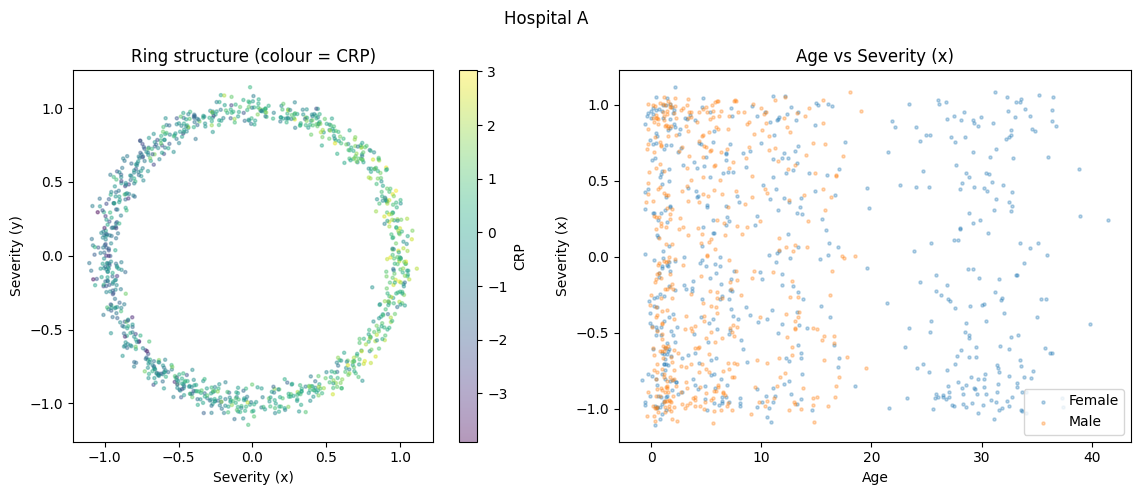

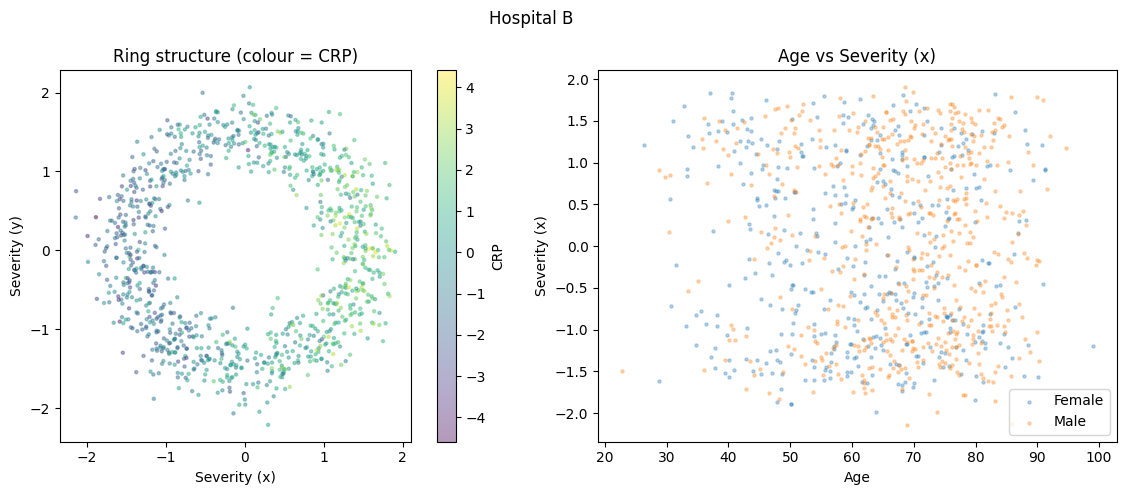

In [7]:
# Plot age vs severity (coloured by sex) and the severity_x vs severity_y ring structure (coloured by CRP) for a hospital

def plot_hospital(X, y, title):
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    crp = X[:, 3]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Left: severity_x vs severity_y (the ring itself)
    sc = axes[0].scatter(X[:, 1], X[:, 2], c=crp, cmap='viridis', s=5, alpha=0.4)
    axes[0].set_xlabel("Severity (x)")
    axes[0].set_ylabel("Severity (y)")
    axes[0].set_title("Ring structure (colour = CRP)")
    axes[0].set_aspect('equal')
    fig.colorbar(sc, ax=axes[0], label="CRP")

    # Right: age vs severity_x, coloured by sex
    axes[1].scatter(X[y == 1, 0], X[y == 1, 1], s=5, alpha=0.3, label="Female")
    axes[1].scatter(X[y == 0, 0], X[y == 0, 1], s=5, alpha=0.3, label="Male")
    axes[1].set_xlabel("Age")
    axes[1].set_ylabel("Severity (x)")
    axes[1].set_title("Age vs Severity (x)")
    axes[1].legend(loc="lower right")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_hospital(X_A, y_A, "Hospital A")
plot_hospital(X_B, y_B, "Hospital B")

In [8]:
#Normalise scales
def preprocess(X_A, X_B, y_A, y_B):
    X_pool = np.vstack([X_A, X_B])
    scaler = StandardScaler().fit(X_pool)
    columns = ["age", "severity_x", "severity_y", "crp", "gender"]
    X_A_full = pd.DataFrame(np.column_stack([scaler.transform(X_A), y_A]), columns=columns)
    X_B_full = pd.DataFrame(np.column_stack([scaler.transform(X_B), y_B]), columns=columns)
    return X_A_full, X_B_full

X_A_scaled, X_B_scaled = preprocess(X_A, X_B, y_A, y_B)

In [9]:
# Compute persistence diagrams
def get_diagrams(X, max_dim=1):
    result = ripser(X, maxdim=max_dim)
    return result['dgms']
dgms_A = get_diagrams(X_A_scaled)
dgms_B = get_diagrams(X_B_scaled)

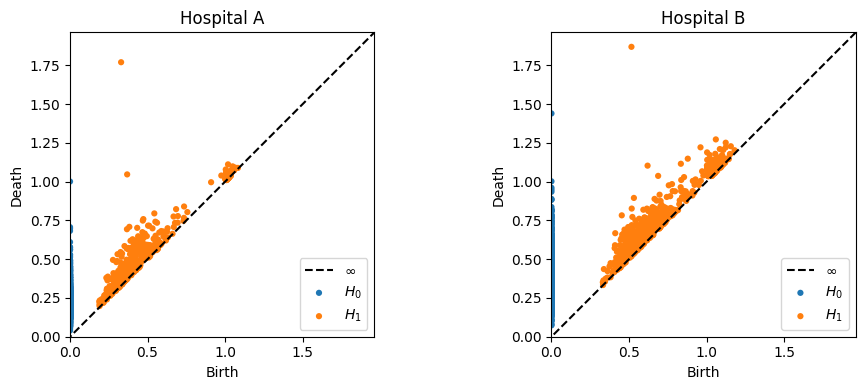

In [10]:
# Plot persistence diagrams
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Compute a shared axis limit across both diagrams ---
all_finite_vals = []
for dgms in [dgms_A, dgms_B]:
    for dgm in dgms:
        finite = dgm[np.isfinite(dgm[:, 1])]
        if finite.size > 0:
            all_finite_vals.append(finite.max())
axis_max = max(all_finite_vals) * 1.05

for ax, dgms, title in zip(axes, [dgms_A, dgms_B], ["Hospital A", "Hospital B"]):
    plt.sca(ax)
    plot_diagrams(dgms, show=False)
    ax.set_title(title)
    ax.set_xlim(0, axis_max)
    ax.set_ylim(0, axis_max)

plt.tight_layout()
plt.show()

In [13]:
# Compute distance matrix, less computationally expensive
def precompute_distances(diagrams, dim=1, order=2, internal_p=2):
    m = len(diagrams)
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i+1, m):
            if order == np.inf:
                d = gudhi.bottleneck_distance(diagrams[i][dim], diagrams[j][dim])
            else:
                d = wasserstein_distance(diagrams[i][dim], diagrams[j][dim],
                    order=order, internal_p=internal_p)
            D[i, j] = d
            D[j, i] = d
    return D

In [14]:
# Sample persistence diagrams without replacement to ensure independence

def sample_diagrams_nonoverlapping(X, n_subsamples, subsample_size, seed=0):
    rng = np.random.default_rng(seed)
    X_arr = np.asarray(X)
    n = len(X_arr)
    assert n_subsamples * subsample_size <= n, (
        f"Not enough patients: need {n_subsamples * subsample_size}, have {n}"
    )
    idx_all = rng.permutation(n)
    diagrams = []
    for i in range(n_subsamples):
        idx = idx_all[i * subsample_size : (i + 1) * subsample_size]
        dgms = get_diagrams(X_arr[idx], max_dim=1)
        diagrams.append(dgms)
    return diagrams

In [15]:
# Compute Inco-variance as defined in Krebs and Rademacher paper (Section 4.1)
def inco_variance_from_matrix(D):
    m = len(D)
    return np.sum(0.5 * D**2) / (m * (m - 1))

In [16]:
# Compute the two sample incovariance test Krebs and Rademacher (Section 4.1 in the dissertation)

def two_sample_test(dgms_A_samples, dgms_B_samples, dim=1, delta=0.01, n_boot=1000, seed=0):
    rng = np.random.default_rng(seed)
    D_A = precompute_distances(dgms_A_samples, dim)
    D_B = precompute_distances(dgms_B_samples, dim)
    m, n = len(D_A), len(D_B)

    sigma2_A = inco_variance_from_matrix(D_A)
    sigma2_B = inco_variance_from_matrix(D_B)
    diff = sigma2_A - sigma2_B

    boot_diffs = []
    for _ in range(n_boot):
        idx_a = rng.choice(m, size=m, replace=True)
        idx_b = rng.choice(n, size=n, replace=True)
        s2_a = inco_variance_from_matrix(D_A[np.ix_(idx_a, idx_a)])
        s2_b = inco_variance_from_matrix(D_B[np.ix_(idx_b, idx_b)])
        boot_diffs.append(s2_a - s2_b)

    se = np.std(boot_diffs)
    scaled_delta = delta * (sigma2_A + sigma2_B) / 2

    if scaled_delta <= 0:
        raise ValueError(
            "delta must be > 0: the delta-method correction 2*sqrt(scaled_delta) "
            "is undefined at scaled_delta = 0."
        )

    T = np.sqrt(m * n / (m + n)) * (diff**2 - scaled_delta) /(2*np.sqrt(scaled_delta)*se)
    p_value = 1 - norm.cdf(T)

    return {"sigma2_A": sigma2_A, "sigma2_B": sigma2_B,
            "diff": diff, "T": T, "p_value": p_value}

In [17]:
# Compute F joint loss as deined in Robinson and Turner (Section 4.2)

def F_from_distance_matrix(D, idx_groups, q=2):
    total = 0.0
    for idx_m in idx_groups:
        n_m = len(idx_m)
        D_m = D[np.ix_(idx_m, idx_m)]
        sigma2_m = np.sum(D_m**q)
        total += sigma2_m / (2 * n_m * (n_m - 1))
    return total

In [18]:
# Use F joint loss to compute permutation test, Robinson and Turner (Section 4.2)

def permutation_test(dgms_samples_list, n_perms=1000, dim=1, order=2, internal_p=2, q=2, seed=0):
    rng = np.random.default_rng(seed)

    pooled_dgms = sum(dgms_samples_list, [])
    group_sizes = [len(d) for d in dgms_samples_list]
    labels = np.concatenate([
        np.full(n_m, m) for m, n_m in enumerate(group_sizes)
    ])

    D_pooled = precompute_distances(pooled_dgms, dim, order, internal_p)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(dgms_samples_list))]
    F_L_obs = F_from_distance_matrix(D_pooled, idx_groups_obs, q=q)

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(dgms_samples_list))]
        F_L = F_from_distance_matrix(D_pooled, idx_groups_perm, q=q)
        if F_L <= F_L_obs:
            Z += 1

    return Z / (n_perms + 1)

In [19]:
# Using python package PersLandscapeApprox developed following Bubekin's paper we compute the landscape for each persistence diagram (Section 4.3)
# stack_and_pad ensures all landscape matrices have the same dimension so landscapes can be compared

def safe_landscape_values(dgms, hom_deg, num_steps, start, stop):
    values_list = []
    for dgm in dgms:
        sub_arr = np.asarray(dgm[hom_deg])
        finite = sub_arr[np.isfinite(sub_arr).all(axis=1)] if sub_arr.size > 0 else sub_arr
        if finite.shape[0] == 0:
            values_list.append(np.zeros((1, num_steps)))
        else:
            pl = PersLandscapeApprox(dgms=dgm, hom_deg=hom_deg, num_steps=num_steps,
                                      start=start, stop=stop)
            values_list.append(pl.values)
    return values_list


def stack_and_pad(values_list, num_steps):
    K = max(v.shape[0] for v in values_list)
    padded = [np.vstack([v, np.zeros((K - v.shape[0], num_steps))]) if v.shape[0] < K else v
              for v in values_list]
    return np.array(padded)

In [20]:
# Compute the persistence landscape for every diagram in a list of diagrams

def pers_landscape(dgms, hom_deg=1, num_steps=500, start=None, stop=None):
    landscapes = []
    for dgm in dgms:
        pl = PersLandscapeApprox(dgms=dgm, hom_deg=hom_deg, num_steps=num_steps,
            start=start, stop=stop)
        landscapes.append(pl)
    return landscapes

In [21]:
# Stack per-sample landscapes into a common array and define the between-group landscape test statistic:
# for each group, sum the squared distance between its mean landscape and the overall mean landscape,
# where the sum over the landscape's function-value axis approximates ∫(diff)^2 via a Riemann sum with step dt,
# and levels (rows of the landscape) are then summed together.

def precompute_all_landscapes(dgms_list, hom_deg, global_start, global_stop, num_steps=500):

    values_list = safe_landscape_values(dgms_list, hom_deg, num_steps, global_start, global_stop)
    stacked = stack_and_pad(values_list, num_steps)  # shape (n_samples, K, num_steps)
    return stacked


def landscape_statistic_from_stacks(stacks, dt):
    K = max(s.shape[1] for s in stacks)
    num_steps = stacks[0].shape[2]

    padded_stacks = []
    for s in stacks:
        if s.shape[1] < K:
            pad = np.zeros((s.shape[0], K - s.shape[1], num_steps))
            s = np.concatenate([s, pad], axis=1)
        padded_stacks.append(s)

    group_means = [s.mean(axis=0) for s in padded_stacks]

    overall_mean = np.mean(np.stack(group_means, axis=0), axis=0)

    total = 0.0
    for gm in group_means:
        diff = gm - overall_mean
        total += np.sum(diff**2) * dt

    return total

In [22]:
# Permutation test on the landscape statistic: compare the observed between-group statistic to its
# null distribution obtained by randomly relabelling samples across groups

def permutation_landscapes(dgms_samples_list, global_start, global_stop,
                            n_perms=1000, hom_deg=1, seed=0, num_steps=500):
    rng = np.random.default_rng(seed)
    dt = (global_stop - global_start) / (num_steps - 1)

    pooled_dgms = sum(dgms_samples_list, [])
    group_sizes = [len(d) for d in dgms_samples_list]
    labels = np.concatenate([
        np.full(n_m, m) for m, n_m in enumerate(group_sizes)
    ])

    pooled_stack = precompute_all_landscapes(pooled_dgms, hom_deg, global_start, global_stop, num_steps)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(dgms_samples_list))]
    stat_obs = landscape_statistic_from_stacks(
        [pooled_stack[idx] for idx in idx_groups_obs], dt
    )

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(dgms_samples_list))]

        stat_L = landscape_statistic_from_stacks(
            [pooled_stack[idx] for idx in idx_groups_perm], dt
        )

        if stat_L >= stat_obs:
            Z += 1

    return Z / (n_perms + 1)

In [23]:
# Two-sample z-test comparing the total landscape mass (area under the landscape curve) between two groups

def landscape_ztest(dgms_A, dgms_B, hom_deg, global_start, global_stop, num_steps=500):
    dt = (global_stop - global_start) / (num_steps - 1)

    landscape_A = pers_landscape(dgms_A, hom_deg=hom_deg, num_steps=num_steps,
                                  start=global_start, stop=global_stop)
    landscape_B = pers_landscape(dgms_B, hom_deg=hom_deg, num_steps=num_steps,
                                  start=global_start, stop=global_stop)

    Y_A = np.array([np.sum(pl.values) * dt for pl in landscape_A])
    Y_B = np.array([np.sum(pl.values) * dt for pl in landscape_B])

    n_A, n_B = len(Y_A), len(Y_B)
    mean_A, mean_B = Y_A.mean(), Y_B.mean()
    var_A, var_B = Y_A.var(ddof=1), Y_B.var(ddof=1)

    se = np.sqrt(var_A / n_A + var_B / n_B)
    z = (mean_A - mean_B) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return z, p_value

In [24]:
# Can also restrict to certain ks only, i.e. the first two most significant. Useful to localise which layer k is driving a detected difference
def landscape_ztest_k(dgms_A, dgms_B, k, hom_deg, global_start, global_stop, num_steps=500):
    dt = (global_stop - global_start) / (num_steps - 1)

    landscape_A = pers_landscape(dgms_A, hom_deg=hom_deg, num_steps=num_steps,
                                  start=global_start, stop=global_stop)
    landscape_B = pers_landscape(dgms_B, hom_deg=hom_deg, num_steps=num_steps,
                                  start=global_start, stop=global_stop)

    K = landscape_A[0].values.shape[0]
    if k < 1 or k > K:
        raise ValueError(f"k={k} out of range; landscapes only have {K} layers (1 to {K})")

    row = k - 1
    Y_A = np.array([pl.values[row, :].sum() * dt for pl in landscape_A])
    Y_B = np.array([pl.values[row, :].sum() * dt for pl in landscape_B])

    n_A, n_B = len(Y_A), len(Y_B)
    mean_A, mean_B = Y_A.mean(), Y_B.mean()
    var_A, var_B = Y_A.var(ddof=1), Y_B.var(ddof=1)
    se = np.sqrt(var_A / n_A + var_B / n_B)

    if se == 0:
        return {"k": k, "z": np.nan, "p_value": np.nan,
                "mean_A": mean_A, "mean_B": mean_B, "note": "zero variance — likely all-zero layer"}

    z = (mean_A - mean_B) / se
    p_value = 2 * (1 - norm.cdf(abs(z)))

    return {"k": k, "z": z, "p_value": p_value, "mean_A": mean_A, "mean_B": mean_B}

In [25]:
# Find the global birth/death range across all pooled diagrams, so landscapes can be evaluated on a common grid

def get_global_range(dgms_list, hom_deg):
    pooled = sum(dgms_list, [])
    all_vals = []
    for d in pooled:
        arr = np.asarray(d[hom_deg])
        if arr.size == 0:
            continue
        finite = arr[np.isfinite(arr).all(axis=1)]
        if finite.size > 0:
            all_vals.append(finite)
    all_vals = np.concatenate(all_vals, axis=0)
    return all_vals.min(), all_vals.max()

In [26]:
# Calculate Frobenius distance between sample correlation matrix and independent (identity) matrix
def correlation_matrix_distance(X):
    C = np.corrcoef(X, rowvar=False)
    I = np.eye(C.shape[0])
    return np.linalg.norm(C - I, 'fro')

In [27]:
# Standardise continuous features (leaving discrete ones untouched), as required before mutual information estimation

def prepare_for_mi(X, discrete_mask):
    X_mi = X.copy()
    continuous_idx = [i for i, d in enumerate(discrete_mask) if not d]
    X_mi[:, continuous_idx] = StandardScaler().fit_transform(X_mi[:, continuous_idx])
    return X_mi

In [28]:
# Compute the pairwise mutual information matrix across features
# (classification MI when the second feature is discrete, regression MI otherwise)

def pairwise_mi_matrix(X, discrete_mask, n_neighbors=3, random_state=42):
    n_features = X.shape[1]
    M = np.zeros((n_features, n_features))
    discrete_mask = np.asarray(discrete_mask)

    for j in range(n_features):
        for k in range(j + 1, n_features):
            Xj = X[:, [j]]
            yk = X[:, k]

            if discrete_mask[k]:
                mi = mutual_info_classif(
                    Xj, yk.astype(int),
                    discrete_features=[discrete_mask[j]],
                    n_neighbors=n_neighbors, random_state=random_state
                )[0]
            else:
                mi = mutual_info_regression(
                    Xj, yk,
                    discrete_features=[discrete_mask[j]],
                    n_neighbors=n_neighbors, random_state=random_state
                )[0]

            M[j, k] = M[k, j] = mi

    return M

In [29]:
# Frobenius norm of the mutual information matrix, used as a single summary measure of feature dependence

def mi_frobenius_norm(M):
    return np.linalg.norm(M, ord='fro')

In [30]:
# Wasserstein distance test on the raw data

def precompute_distances_raw(X_samples, order=2):
    m = len(X_samples)
    D = np.zeros((m, m))
    for i in range(m):
        for j in range(i + 1, m):
            a = np.ones(len(X_samples[i])) / len(X_samples[i])
            b = np.ones(len(X_samples[j])) / len(X_samples[j])
            M = ot.dist(X_samples[i], X_samples[j], metric='sqeuclidean')  # squared L2 ground cost
            d = ot.emd2(a, b, M) ** 0.5   # sqrt gives true W_2 distance
            D[i, j] = D[j, i] = d
    return D

In [31]:
# Permutation test analogous to permutation_test(), but run directly on raw covariate subsamples instead of persistence diagrams

def permutation_test_raw(X_samples_list, n_perms=1000, order=2, q=2, seed=0):
    rng = np.random.default_rng(seed)

    pooled_samples = sum(X_samples_list, [])
    group_sizes = [len(s) for s in X_samples_list]
    labels = np.concatenate([np.full(n_m, m) for m, n_m in enumerate(group_sizes)])

    D_pooled = precompute_distances_raw(pooled_samples, order=order)

    idx_groups_obs = [np.where(labels == m)[0] for m in range(len(X_samples_list))]
    F_L_obs = F_from_distance_matrix(D_pooled, idx_groups_obs, q=q)

    Z = 1
    for i in range(1, n_perms):
        shuffled_labels = rng.permutation(labels)
        idx_groups_perm = [np.where(shuffled_labels == m)[0] for m in range(len(X_samples_list))]
        F_L = F_from_distance_matrix(D_pooled, idx_groups_perm, q=q)
        if F_L <= F_L_obs:
            Z += 1

    return Z / (n_perms + 1)

In [32]:
# Draw non-overlapping subsamples of raw covariate rows (parallel to sample_diagrams_nonoverlapping, but returns raw data instead of persistence diagrams)
def sample_raw_nonoverlapping(X, n_subsamples=6, subsample_size=50, seed=0):
    rng = np.random.default_rng(seed)
    n_needed = n_subsamples * subsample_size
    assert n_needed <= len(X), f"Need {n_needed} rows, only have {len(X)}"

    idx = rng.permutation(len(X))[:n_needed]
    return [X[idx[i*subsample_size:(i+1)*subsample_size]] for i in range(n_subsamples)]

In [33]:
# Main simulation loop: for each iteration, resample hospital data and compute
# (1) non-topological baselines (correlation-matrix distance, mutual information), and
# (2) TDA-based two-sample tests on H0 (dimension-0) and H1 (dimension-1) persistence diagrams —
#     inco-variance test, Robinson & Turner permutation test, landscape permutation test, and landscape z-test

covariate_cols = ["age", "severity", "crp", "gender"]
discrete_mask = [False, False, False, True]
synthetic_groups = ["A", "B"]

n_iterations = 20
results = {
    "H0_sigma2_A": [], "H0_sigma2_B": [], "H0_pvalue": [],
    "H1_sigma2_A": [], "H1_sigma2_B": [], "H1_pvalue": [],
    "H0_perm_pvalue": [], "H1_perm_pvalue": [],
    "H0_landscape_perm_pvalue": [], "H1_landscape_perm_pvalue": [],
    "H0_landscape_ztest_z": [], "H1_landscape_ztest_z": [],
    "H0_landscape_ztest_pvalue": [], "H1_landscape_ztest_pvalue": [],
    "corr_dist": [], "mi_frob": [],
    "raw_wasserstein_perm_pvalue": [],
}

n_perms = 1000

with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message=".*non-finite death times.*")

    for it in range(n_iterations):
        print(f"Iteration {it+1}/{n_iterations}...")

        X_A, y_A = data_hospital(A, n=1000)
        X_B, y_B = data_hospital(B, n=1000)
        X_A_scaled_df, X_B_scaled_df = preprocess(X_A, X_B, y_A, y_B)
        X_A_scaled = X_A_scaled_df.values
        X_B_scaled = X_B_scaled_df.values

        # --- non-topological baselines ---
        corr_dist_by_group = {
            "A": correlation_matrix_distance(X_A_scaled),
            "B": correlation_matrix_distance(X_B_scaled),
        }

        mi_col_idx = [0, 1, 3]   # age, severity, gender
        mi_discrete_mask = [False, False, True]
        mi_frob_by_group = {
            "A": mi_frobenius_norm(pairwise_mi_matrix(X_A_scaled[:, mi_col_idx], mi_discrete_mask, n_neighbors=3, random_state=it)),
            "B": mi_frobenius_norm(pairwise_mi_matrix(X_B_scaled[:, mi_col_idx], mi_discrete_mask, n_neighbors=3, random_state=it)),}
        results["corr_dist"].append(corr_dist_by_group)
        results["mi_frob"].append(mi_frob_by_group)

        # --- Raw-data Wasserstein permutation test  ---
        X_A_samples = sample_raw_nonoverlapping(X_A_scaled, n_subsamples=20, subsample_size=50, seed=it)
        X_B_samples = sample_raw_nonoverlapping(X_B_scaled, n_subsamples=20, subsample_size=50, seed=it)
        X_samples_list = [X_A_samples, X_B_samples]

        raw_perm_pvalue = permutation_test_raw(X_samples_list, n_perms=n_perms, order=2, q=2, seed=it)
        results["raw_wasserstein_perm_pvalue"].append(raw_perm_pvalue)

        # --- TDA diagrams ---
        dgms_A_samples = sample_diagrams_nonoverlapping(X_A_scaled, n_subsamples=20, subsample_size=50)
        dgms_B_samples = sample_diagrams_nonoverlapping(X_B_scaled, n_subsamples=20, subsample_size=50)
        dgms_samples_list = [dgms_A_samples, dgms_B_samples]

        for dim, key in [(0, "H0"), (1, "H1")]:
            result = two_sample_test(dgms_A_samples, dgms_B_samples, dim=dim, delta = 0.01)
            results[f"{key}_sigma2_A"].append(result["sigma2_A"])
            results[f"{key}_sigma2_B"].append(result["sigma2_B"])
            results[f"{key}_pvalue"].append(result["p_value"])

            perm_pvalue = permutation_test(dgms_samples_list, n_perms=n_perms, dim=dim, seed=it)
            results[f"{key}_perm_pvalue"].append(perm_pvalue)

            g_start, g_stop = get_global_range(dgms_samples_list, hom_deg=dim)

            landscape_perm_pvalue = permutation_landscapes(
                dgms_samples_list, global_start=g_start, global_stop=g_stop,
                n_perms=n_perms, hom_deg=dim, seed=it
            )
            results[f"{key}_landscape_perm_pvalue"].append(landscape_perm_pvalue)

            z, ztest_pvalue = landscape_ztest(
                dgms_A_samples, dgms_B_samples,
                hom_deg=dim, global_start=g_start, global_stop=g_stop
            )
            results[f"{key}_landscape_ztest_z"].append(z)
            results[f"{key}_landscape_ztest_pvalue"].append(ztest_pvalue)

Iteration 1/20...
Iteration 2/20...
Iteration 3/20...
Iteration 4/20...
Iteration 5/20...
Iteration 6/20...
Iteration 7/20...
Iteration 8/20...
Iteration 9/20...
Iteration 10/20...
Iteration 11/20...
Iteration 12/20...
Iteration 13/20...
Iteration 14/20...
Iteration 15/20...
Iteration 16/20...
Iteration 17/20...
Iteration 18/20...
Iteration 19/20...
Iteration 20/20...


In [34]:
# Report rejection rates (proportion of p-values < 0.05) for each test using H1 (dimension-1) diagrams

h1_incovariance_pvals = np.array(results["H1_pvalue"])
print("Inco-variance rejection rate (H1):", np.mean(h1_incovariance_pvals < 0.05))

h1_landscape_ztest_pvals = np.array(results["H1_landscape_ztest_pvalue"])
print("Landscape z-test rejection rate (H1):", np.mean(h1_landscape_ztest_pvals < 0.05))

h1_rt_perm_pvals = np.array(results["H1_perm_pvalue"])
print("R&T permutation rejection rate (H1):", np.mean(h1_rt_perm_pvals < 0.05))

h1_landscape_perm_pvals = np.array(results["H1_landscape_perm_pvalue"])
print("Landscape permutation rejection rate (H1):", np.mean(h1_landscape_perm_pvals < 0.05))

Inco-variance rejection rate (H1): 0.8
Landscape z-test rejection rate (H1): 0.75
R&T permutation rejection rate (H1): 1.0
Landscape permutation rejection rate (H1): 1.0


In [35]:
# Report rejection rates (proportion of p-values < 0.05) for each test using H0 (dimension-0) diagrams

h0_incovariance_pvals = np.array(results["H0_pvalue"])
print("Inco-variance rejection rate (H0):", np.mean(h0_incovariance_pvals < 0.05))

h0_landscape_ztest_pvals = np.array(results["H0_landscape_ztest_pvalue"])
print("Landscape z-test rejection rate (H0):", np.mean(h0_landscape_ztest_pvals < 0.05))

h0_rt_perm_pvals = np.array(results["H0_perm_pvalue"])
print("R&T permutation rejection rate (H0):", np.mean(h0_rt_perm_pvals < 0.05))

h0_landscape_perm_pvals = np.array(results["H0_landscape_perm_pvalue"])
print("Landscape permutation rejection rate (H0):", np.mean(h0_landscape_perm_pvals < 0.05))

Inco-variance rejection rate (H0): 0.45
Landscape z-test rejection rate (H0): 1.0
R&T permutation rejection rate (H0): 1.0
Landscape permutation rejection rate (H0): 1.0


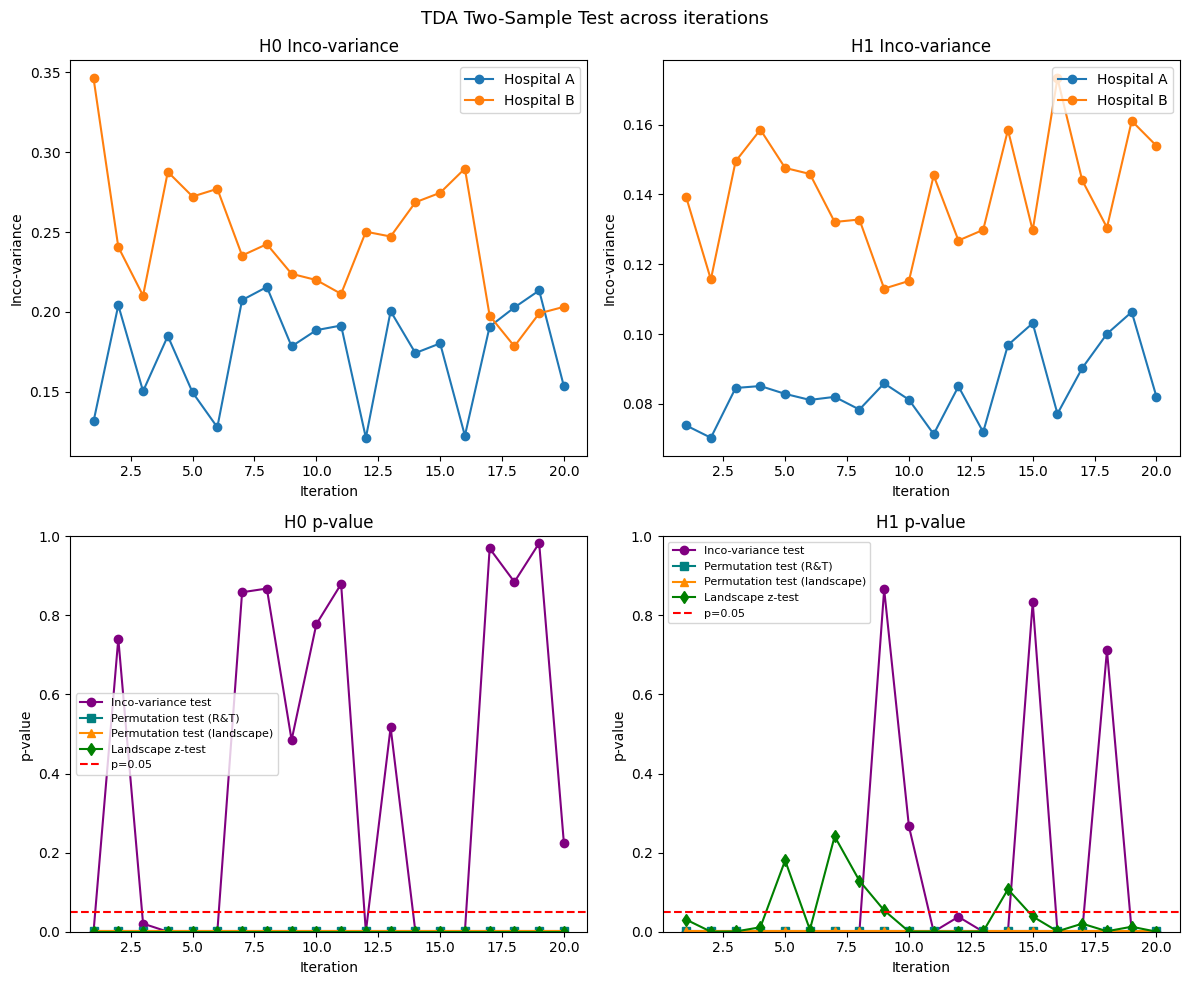

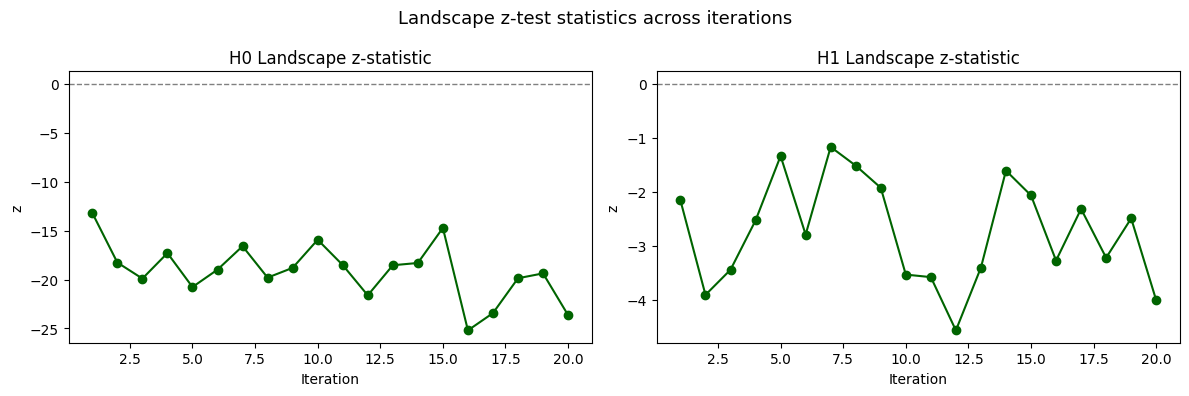

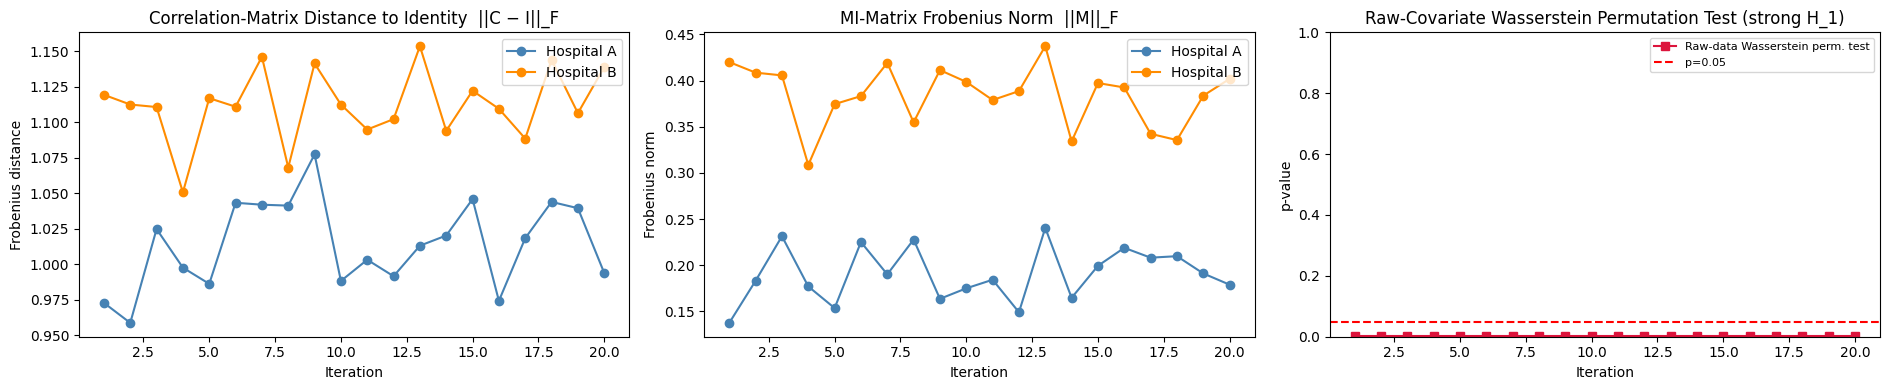

In [36]:
# Plot inco-variance values and test p-values across iterations, for both hospitals and all four test methods

corr_dist_by_group_series = {g: [d[g] for d in results["corr_dist"]] for g in synthetic_groups}
mi_frob_by_group_series = {g: [d[g] for d in results["mi_frob"]] for g in synthetic_groups}
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
iters = range(1, n_iterations + 1)

axes[0, 0].plot(iters, results["H0_sigma2_A"], label="Hospital A", marker="o")
axes[0, 0].plot(iters, results["H0_sigma2_B"], label="Hospital B", marker="o")
axes[0, 0].set_title("H0 Inco-variance")
axes[0, 0].set_ylabel("Inco-variance")
axes[0, 0].legend()

axes[0, 1].plot(iters, results["H1_sigma2_A"], label="Hospital A", marker="o")
axes[0, 1].plot(iters, results["H1_sigma2_B"], label="Hospital B", marker="o")
axes[0, 1].set_title("H1 Inco-variance")
axes[0, 1].set_ylabel("Inco-variance")
axes[0, 1].legend(loc='upper right')

axes[1, 0].plot(iters, results["H0_pvalue"], marker="o", color="purple", label="Inco-variance test")
axes[1, 0].plot(iters, results["H0_perm_pvalue"], marker="s", color="teal", label="Permutation test (R&T)")
axes[1, 0].plot(iters, results["H0_landscape_perm_pvalue"], marker="^", color="darkorange", label="Permutation test (landscape)")
axes[1, 0].plot(iters, results["H0_landscape_ztest_pvalue"], marker="d", color="green", label="Landscape z-test")
axes[1, 0].axhline(0.05, color="red", linestyle="--", label="p=0.05")
axes[1, 0].set_title("H0 p-value")
axes[1, 0].set_ylabel("p-value")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].legend(fontsize=8)

axes[1, 1].plot(iters, results["H1_pvalue"], marker="o", color="purple", label="Inco-variance test")
axes[1, 1].plot(iters, results["H1_perm_pvalue"], marker="s", color="teal", label="Permutation test (R&T)")
axes[1, 1].plot(iters, results["H1_landscape_perm_pvalue"], marker="^", color="darkorange", label="Permutation test (landscape)")
axes[1, 1].plot(iters, results["H1_landscape_ztest_pvalue"], marker="d", color="green", label="Landscape z-test")
axes[1, 1].axhline(0.05, color="red", linestyle="--", label="p=0.05")
axes[1, 1].set_title("H1 p-value")
axes[1, 1].set_ylabel("p-value")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend(fontsize=8)

for ax in axes.flat:
    ax.set_xlabel("Iteration")

plt.suptitle("TDA Two-Sample Test across iterations", fontsize=13)
plt.tight_layout()
plt.show()

# --- Landscape z-statistics ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(iters, results["H0_landscape_ztest_z"], marker="o", color="darkgreen")
axes[0].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("H0 Landscape z-statistic")
axes[0].set_ylabel("z")
axes[0].set_xlabel("Iteration")

axes[1].plot(iters, results["H1_landscape_ztest_z"], marker="o", color="darkgreen")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("H1 Landscape z-statistic")
axes[1].set_ylabel("z")
axes[1].set_xlabel("Iteration")

plt.suptitle("Landscape z-test statistics across iterations", fontsize=13)
plt.tight_layout()
plt.show()

# --- Correlation matrix distance, MI Frobenius norm, raw-data Wasserstein test ---
corr_dist_A = [d["A"] for d in results["corr_dist"]]
corr_dist_B = [d["B"] for d in results["corr_dist"]]
mi_frob_A = [d["A"] for d in results["mi_frob"]]
mi_frob_B = [d["B"] for d in results["mi_frob"]]

fig, axes = plt.subplots(1, 3, figsize=(19, 4))

axes[0].plot(iters, corr_dist_A, marker="o", color="steelblue", label="Hospital A")
axes[0].plot(iters, corr_dist_B, marker="o", color="darkorange", label="Hospital B")
axes[0].set_title("Correlation-Matrix Distance to Identity  ||C − I||_F")
axes[0].set_ylabel("Frobenius distance")
axes[0].set_xlabel("Iteration")
axes[0].legend(loc='upper right')

axes[1].plot(iters, mi_frob_A, marker="o", color="steelblue", label="Hospital A")
axes[1].plot(iters, mi_frob_B, marker="o", color="darkorange", label="Hospital B")
axes[1].set_title("MI-Matrix Frobenius Norm  ||M||_F")
axes[1].set_ylabel("Frobenius norm")
axes[1].set_xlabel("Iteration")
axes[1].legend(loc='upper right')

axes[2].plot(iters, results["raw_wasserstein_perm_pvalue"], marker="s", color="crimson", label="Raw-data Wasserstein perm. test")
axes[2].axhline(0.05, color="red", linestyle="--", label="p=0.05")
axes[2].set_title("Raw-Covariate Wasserstein Permutation Test (strong H_1)")
axes[2].set_ylabel("p-value")
axes[2].set_xlabel("Iteration")
axes[2].set_ylim(0, 1)
axes[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

In [37]:
# Summarise mean, standard deviation, and % significant (p<0.05) for every test into one results table
cmd_A_vals = np.array([d["A"] for d in results["corr_dist"]])
cmd_B_vals = np.array([d["B"] for d in results["corr_dist"]])
cmd_diff = cmd_A_vals - cmd_B_vals

summary = pd.DataFrame({
    "Metric": [
        "CMD Hospital A  ||C−I||_F",
        "CMD Hospital B  ||C−I||_F",
        "CMD difference (A − B)",
        "H0 p-value (inco-variance)",
        "H1 p-value (inco-variance)",
        "H0 p-value (permutation, R&T)",
        "H1 p-value (permutation, R&T)",
        "H0 p-value (permutation, landscape)",
        "H1 p-value (permutation, landscape)",
        "H0 p-value (landscape z-test)",
        "H1 p-value (landscape z-test)",
    ],
    "Mean": [
        np.mean(cmd_A_vals),
        np.mean(cmd_B_vals),
        np.mean(cmd_diff),
        np.mean(results["H0_pvalue"]),
        np.mean(results["H1_pvalue"]),
        np.mean(results["H0_perm_pvalue"]),
        np.mean(results["H1_perm_pvalue"]),
        np.mean(results["H0_landscape_perm_pvalue"]),
        np.mean(results["H1_landscape_perm_pvalue"]),
        np.mean(results["H0_landscape_ztest_pvalue"]),
        np.mean(results["H1_landscape_ztest_pvalue"]),
    ],
    "Std": [
        np.std(cmd_A_vals),
        np.std(cmd_B_vals),
        np.std(cmd_diff),
        np.std(results["H0_pvalue"]),
        np.std(results["H1_pvalue"]),
        np.std(results["H0_perm_pvalue"]),
        np.std(results["H1_perm_pvalue"]),
        np.std(results["H0_landscape_perm_pvalue"]),
        np.std(results["H1_landscape_perm_pvalue"]),
        np.std(results["H0_landscape_ztest_pvalue"]),
        np.std(results["H1_landscape_ztest_pvalue"]),
    ],
    "% significant (p<0.05)": [
        "-", "-", "-",
        f"{np.mean(np.array(results['H0_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H1_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H0_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H1_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H0_landscape_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H1_landscape_perm_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H0_landscape_ztest_pvalue']) < 0.05) * 100:.0f}%",
        f"{np.mean(np.array(results['H1_landscape_ztest_pvalue']) < 0.05) * 100:.0f}%",
    ],
})
print(summary.to_string(index=False))

                             Metric      Mean          Std % significant (p<0.05)
          CMD Hospital A  ||C−I||_F  1.013879 3.013939e-02                      -
          CMD Hospital B  ||C−I||_F  1.112146 2.515286e-02                      -
             CMD difference (A − B) -0.098267 3.530512e-02                      -
         H0 p-value (inco-variance)  0.410365 4.056510e-01                    45%
         H1 p-value (inco-variance)  0.135773 2.876125e-01                    80%
      H0 p-value (permutation, R&T)  0.000999 2.168404e-19                   100%
      H1 p-value (permutation, R&T)  0.000999 2.168404e-19                   100%
H0 p-value (permutation, landscape)  0.000999 2.168404e-19                   100%
H1 p-value (permutation, landscape)  0.000999 2.168404e-19                   100%
      H0 p-value (landscape z-test)  0.000000 0.000000e+00                   100%
      H1 p-value (landscape z-test)  0.041750 6.711511e-02                    75%


0.014243709738588888 0.006892776077324457
0.04126255539143859 0.02121727493671801
A: min=0.00, max=0.04
B: min=0.01, max=0.11


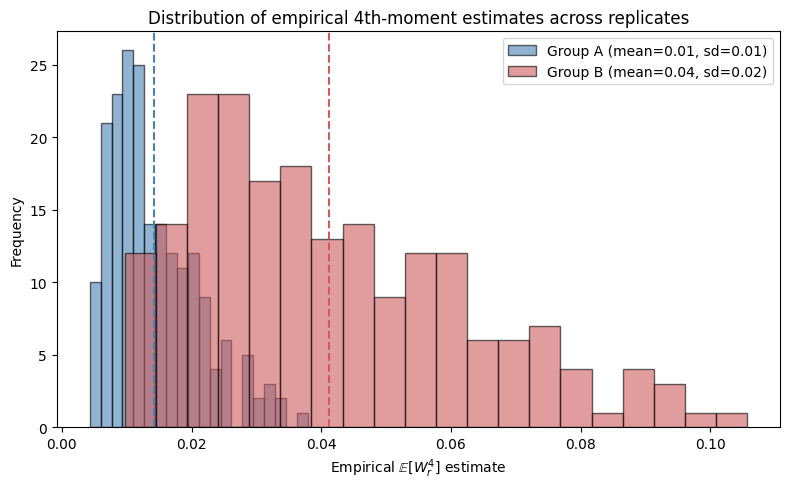

In [38]:
# Check Wasserstein fourth moment convergence
def fourth_moment_check(D):
    fourth_moment_estimate = np.mean(D**4)
    return fourth_moment_estimate

# Assess fourth moment convergence for 200 iterations
i = 0
fourth_A = []
fourth_B = []
while i <200:
  X_A, y_A = data_hospital(A, n=400)
  X_B, y_B = data_hospital(B, n=400)
  X_A_scaled_df, X_B_scaled_df = preprocess(X_A, X_B, y_A, y_B)
  X_A_scaled = X_A_scaled_df.values
  X_B_scaled = X_B_scaled_df.values

  dgms_A_samples = sample_diagrams_nonoverlapping(X_A_scaled, n_subsamples=6, subsample_size=50)
  dgms_B_samples = sample_diagrams_nonoverlapping(X_B_scaled, n_subsamples=6, subsample_size=50)
  W_A = precompute_distances(dgms_A_samples, dim=1, order=2, internal_p=np.inf)
  W_B = precompute_distances(dgms_B_samples, dim=1, order=2, internal_p=np.inf)
  fourth_A.append(fourth_moment_check(W_A))
  fourth_B.append(fourth_moment_check(W_B))
  i += 1

mean_A = np.mean(fourth_A)
mean_B = np.mean(fourth_B)
std_A = np.std(fourth_A)
std_B = np.std(fourth_B)
print(mean_A, std_A)
print(mean_B, std_B)
print(f"A: min={min(fourth_A):.2f}, max={max(fourth_A):.2f}")
print(f"B: min={min(fourth_B):.2f}, max={max(fourth_B):.2f}")

# Plot empirical distribution of the fourth moment
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(fourth_A, bins=20, alpha=0.6, label=f'Group A (mean={mean_A:.2f}, sd={std_A:.2f})', color='steelblue', edgecolor='black')
ax.hist(fourth_B, bins=20, alpha=0.6, label=f'Group B (mean={mean_B:.2f}, sd={std_B:.2f})', color='indianred', edgecolor='black')

ax.axvline(mean_A, color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(mean_B, color='indianred', linestyle='--', linewidth=1.5)

ax.set_xlabel(r'Empirical $\mathbb{E}[W_r^4]$ estimate')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of empirical 4th-moment estimates across replicates')
ax.legend()

plt.tight_layout()
plt.show()

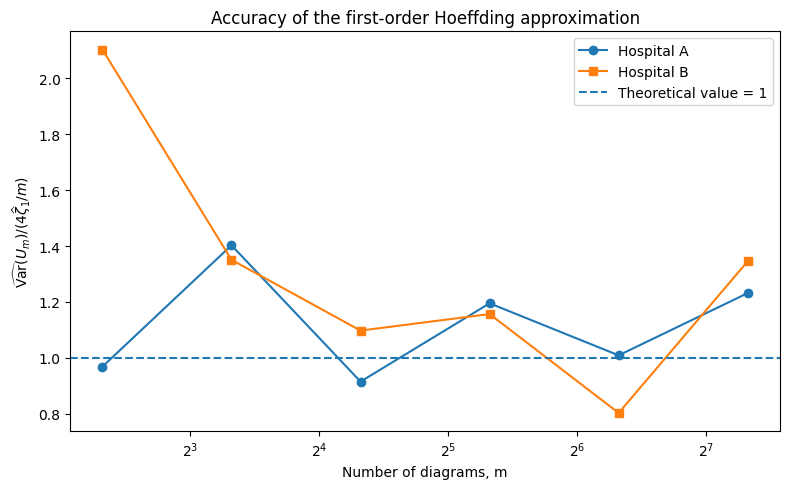

In [39]:
# --- Check approximation of the U-Statistic ---
# We will now construct Hoeffding's decomposition for U-statistics to then assess it's asymptotical variance

# Construct first order projection (h_1)
def h_1(D):
    m = D.shape[0]
    D =  0.5 * D**2
    theta = D.sum() / (m * (m - 1))
    h1 = D.sum(axis=0) / (m - 1) - theta
    return h1

# Construct second order projection (h_2)
def h_2(D, h1):
    m = D.shape[0]
    D =  0.5 * D**2
    theta = D.sum() / (m * (m - 1))
    h2 = D - theta - h1[:, None] - h1[None, :]
    np.fill_diagonal(h2, 0)
    return h2


# Compute U-statistic straight from the pre-computed Wasserstein matrix
def U_statistic(W):
    m = W.shape[0]
    H = 0.5 * W**2
    return H.sum() / (m * (m - 1))

# Compute variance of U-statistic and its first order approximation
# We want to determine if the ratio of the two tends to 1
# We compute it for different number of persistence diagrams (m values)
m_values = [5, 10, 20, 40, 80, 160]
n_reps = 30
subsample_size = 50
results_A = {}
results_B = {}

for m in m_values:
    n_needed = m * subsample_size
    zeta1_A = []
    zeta1_B = []
    U_values_A = []
    U_values_B = []

    for _ in range(n_reps):
        X_A, y_A = data_hospital(A, n=n_needed)
        X_B, y_B = data_hospital(B, n=n_needed)
        X_A_scaled_df, X_B_scaled_df = preprocess(X_A, X_B, y_A, y_B)
        X_A_scaled = X_A_scaled_df.values
        X_B_scaled = X_B_scaled_df.values

        dgms_A_samples = sample_diagrams_nonoverlapping(X_A_scaled, n_subsamples=m, subsample_size=subsample_size)
        dgms_B_samples = sample_diagrams_nonoverlapping(X_B_scaled, n_subsamples=m, subsample_size=subsample_size)
        W_A = precompute_distances(dgms_A_samples, dim=1, order=2, internal_p=np.inf)
        W_B = precompute_distances(dgms_B_samples, dim=1, order=2, internal_p=np.inf)
        h1_A = h_1(W_A)
        h1_B = h_1(W_B)
        U_m_A = U_statistic(W_A)
        U_m_B = U_statistic(W_B)

        zeta1_A.append(np.var(h1_A, ddof=1))
        zeta1_B.append(np.var(h1_B, ddof=1))
        U_values_A.append(U_m_A)
        U_values_B.append(U_m_B)

    mean_zeta1_A = np.mean(zeta1_A)
    mean_zeta1_B = np.mean(zeta1_B)

    results_A[m] = {"zeta1_values": np.asarray(zeta1_A),
                     "U_values": np.asarray(U_values_A),
                     "mean_zeta1": mean_zeta1_A,
                     "empirical_var_U": np.var(U_values_A, ddof=1),
                     "hoeffding_var_U": 4 * mean_zeta1_A / m}
    results_B[m] = {"zeta1_values": np.asarray(zeta1_B),
                     "U_values": np.asarray(U_values_B),
                     "mean_zeta1": mean_zeta1_B,
                     "empirical_var_U": np.var(U_values_B, ddof=1),
                     "hoeffding_var_U": 4 * mean_zeta1_B / m}

# Collect empirical variance of U_m and its first-order Hoeffding approximation (4*zeta1/m) for each m

m_arr = np.asarray(m_values)

emp_var_A = np.array([results_A[m]["empirical_var_U"] for m in m_values])
hoeff_var_A = np.array([results_A[m]["hoeffding_var_U"] for m in m_values])

emp_var_B = np.array([results_B[m]["empirical_var_U"] for m in m_values])
hoeff_var_B = np.array([results_B[m]["hoeffding_var_U"] for m in m_values])

ratio_A = emp_var_A / hoeff_var_A
ratio_B = emp_var_B / hoeff_var_B

# Plot the accuracy (ratio) of the first-order Hoeffding approximation
plt.figure(figsize=(8, 5))

plt.plot(m_arr, ratio_A, marker="o", label="Hospital A")
plt.plot(m_arr, ratio_B, marker="s", label="Hospital B")
plt.axhline(1.0, linestyle="--", label="Theoretical value = 1")

plt.xscale("log", base=2)

plt.xlabel("Number of diagrams, m")
plt.ylabel(
    r"$\widehat{\mathrm{Var}}(U_m)/(4\widehat{\zeta}_1/m)$"
)
plt.title("Accuracy of the first-order Hoeffding approximation")
plt.legend()
plt.tight_layout()
plt.show()

# Collect the mean first-order projection variance (zeta_1) for each m

mean_zeta1_A = np.array([results_A[m]["mean_zeta1"] for m in m_values])
mean_zeta1_B = np.array([results_B[m]["mean_zeta1"] for m in m_values])

Running convergence check for Hospital A...


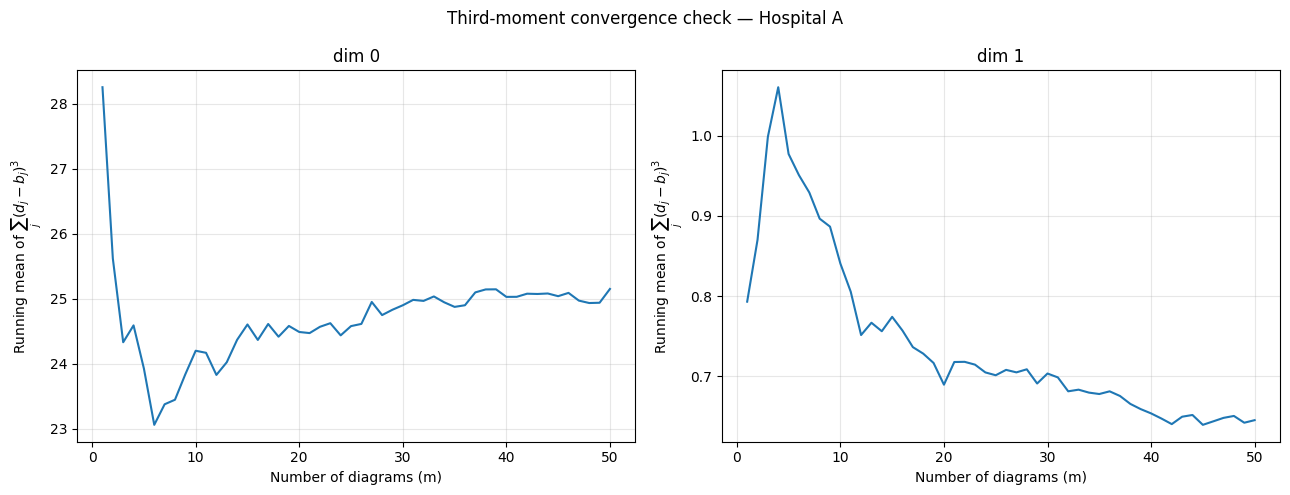

Running convergence check for Hospital B...


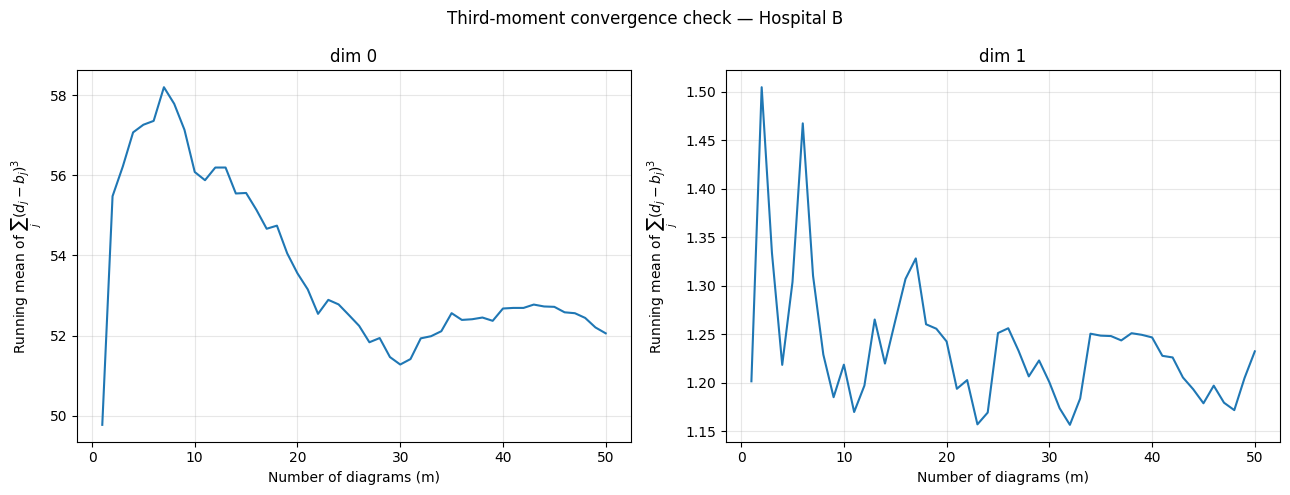

In [40]:
# --- Check convergence of the lanscape norm ---
# Computes sum_j (d_j - b_j)^3 for a single persistence diagram to determine the persistence norm convergence (see appendix B.2 for proof)
def sum_cubed_lifetimes(dgm, hom_deg=1):
    arr = np.asarray(dgm[hom_deg])
    if arr.size == 0:
        return 0.0
    finite = arr[np.isfinite(arr).all(axis=1)]
    if finite.shape[0] == 0:
        return 0.0
    lifetimes = finite[:, 1] - finite[:, 0]  # death - birth
    return np.sum(lifetimes ** 3)

# Samples n_samples diagrams (without replacement) once, then computes
# sum_cubed_lifetimes and the running mean for both homological dimensions
# from the same set of sampled diagrams.

def check_third_moment_convergence_both_dims(X, n_samples=500, subsample_size=50, seed=0):
    dgms_samples = sample_diagrams_nonoverlapping(X, n_subsamples=n_samples,
                                                    subsample_size=subsample_size, seed=seed)

    results = {}
    for hom_deg in [0, 1]:
        values = np.array([sum_cubed_lifetimes(d, hom_deg=hom_deg) for d in dgms_samples])
        running_mean = np.cumsum(values) / np.arange(1, len(values) + 1)
        results[hom_deg] = {"values": values, "running_mean": running_mean}

    return results

# Plot third moment convergence
def plot_third_moment_convergence_both_dims(results, hospital_name=""):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    for ax, hom_deg in zip(axes, [0, 1]):
        running_mean = results[hom_deg]["running_mean"]
        ax.plot(np.arange(1, len(running_mean) + 1), running_mean, linewidth=1.5)
        ax.set_xlabel("Number of diagrams (m)")
        ax.set_ylabel(r"Running mean of $\sum_j (d_j - b_j)^3$")
        ax.set_title(f"dim {hom_deg}")
        ax.grid(alpha=0.3)

    plt.suptitle(f"Third-moment convergence check{' — ' + hospital_name if hospital_name else ''}")
    plt.tight_layout()
    plt.show()

# Run the third-moment convergence check and plot the running mean for each hospital

hospitals_data = {
    "Hospital A": X_A_scaled,
    "Hospital B": X_B_scaled,
}

all_moment_results = {}
for name, X in hospitals_data.items():
    print(f"Running convergence check for {name}...")
    results = check_third_moment_convergence_both_dims(X, n_samples=500, subsample_size=50, seed=0)
    all_moment_results[name] = results
    plot_third_moment_convergence_both_dims(results, hospital_name=name)